In [41]:
from dotenv import load_dotenv
import os
from snowflake.snowpark import Session
from snowflake.snowpark.functions import col, avg, desc
import pandas as pd
import numpy as np

### Connecting to Snowflake

In [42]:
connection_parameters = {
    "account": os.environ["SNOWFLAKE_ACCOUNT"],
    "user": os.environ["SNOWFLAKE_USER"],
    "password": os.environ["SNOWFLAKE_PASSWORD"],
    "role": "SYSADMIN",
    "warehouse": "compute_wh",
    "database": "AIRLINE",
    "schema": "PUBLIC"
}

session = Session.builder.configs(connection_parameters).create()


### Using Snowpark for further analysis

In [43]:
df_snow = session.table('AIRLINE_FINAL')
df_snow.show(5)

----------------------------------------------------------------------------------------------------------------------------------------------------------------------------
|"YEAR"  |"MONTH"  |"DAYOFWEEK"  |"CRSDEPTIME"  |"CRSARRTIME"  |"UNIQUECARRIER"  |"CRSELAPSEDTIME"  |"ARRDELAY"  |"DISTANCE"  |"DEPDELAY"  |"ORIGIN"  |"DEST"  |"ON_TIME"  |
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------
|2003    |7        |6            |1450          |1649          |XE               |119.0             |-3.0        |569         |-4.0        |CVG       |EWR     |1          |
|2003    |7        |5            |845           |1030          |XE               |105.0             |45.0        |529         |50.0        |EWR       |CLT     |0          |
|2003    |7        |2            |1615          |1730          |XE               |75.0              |-8.0        |295         |-3.0    

In [44]:
print(type(df_snow))

<class 'snowflake.snowpark.table.Table'>


In [45]:
df_snow.queries

{'queries': ['SELECT  *  FROM AIRLINE_FINAL'], 'post_actions': []}

In [46]:
df_snow.describe().show()

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
|"SUMMARY"  |"YEAR"           |"MONTH"             |"DAYOFWEEK"        |"CRSDEPTIME"        |"CRSARRTIME"        |"UNIQUECARRIER"  |"CRSELAPSEDTIME"    |"ARRDELAY"         |"DISTANCE"         |"DEPDELAY"          |"ORIGIN"  |"DEST"    |"ON_TIME"            |
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
|mean       |1998.607823      |6.537658            |3.937628           |1339.066253         |1503.084343         |NULL             |120.09402129036185  |4.364542210075646  |694.611107         |5.594443129008391   |NULL     

In [47]:
df_snow.group_by('dayofweek').agg(avg('on_time').alias('avg_on_time_for_day')).order_by('dayofweek').show()

---------------------------------------
|"DAYOFWEEK"  |"AVG_ON_TIME_FOR_DAY"  |
---------------------------------------
|1            |0.574865               |
|2            |0.585236               |
|3            |0.563493               |
|4            |0.537738               |
|5            |0.529497               |
|6            |0.616129               |
|7            |0.577942               |
---------------------------------------



In [48]:
df_snow.group_by('year', 'uniquecarrier').agg(avg('on_time').alias('avg_on_time_for_carrier')).where(col('year') == 1993).order_by(desc('avg_on_time_for_carrier')).show()

--------------------------------------------------------
|"YEAR"  |"UNIQUECARRIER"  |"AVG_ON_TIME_FOR_CARRIER"  |
--------------------------------------------------------
|1993    |WN               |0.641095                   |
|1993    |NW               |0.597617                   |
|1993    |TW               |0.560412                   |
|1993    |US               |0.533918                   |
|1993    |CO               |0.524692                   |
|1993    |AA               |0.498086                   |
|1993    |UA               |0.495570                   |
|1993    |HP               |0.479136                   |
|1993    |AS               |0.438005                   |
|1993    |DL               |0.362167                   |
--------------------------------------------------------



In [49]:
df_snow.group_by('year', 'uniquecarrier').agg(avg('on_time').alias('avg_on_time_for_carrier')).where(col('year') == 2003).order_by(desc('avg_on_time_for_carrier')).show()

--------------------------------------------------------
|"YEAR"  |"UNIQUECARRIER"  |"AVG_ON_TIME_FOR_CARRIER"  |
--------------------------------------------------------
|2003    |HA               |0.695842                   |
|2003    |OO               |0.677436                   |
|2003    |WN               |0.675397                   |
|2003    |UA               |0.640346                   |
|2003    |B6               |0.634298                   |
|2003    |AA               |0.630368                   |
|2003    |MQ               |0.622299                   |
|2003    |NW               |0.613624                   |
|2003    |DH               |0.609375                   |
|2003    |AS               |0.608533                   |
--------------------------------------------------------



In [50]:
df_snow.group_by('month').agg(avg('on_time').alias('avg_on_time_month')).order_by('month').show(12)

---------------------------------
|"MONTH"  |"AVG_ON_TIME_MONTH"  |
---------------------------------
|1        |0.570747             |
|2        |0.534498             |
|3        |0.555551             |
|4        |0.603600             |
|5        |0.605116             |
|6        |0.562858             |
|7        |0.570588             |
|8        |0.558449             |
|9        |0.613712             |
|10       |0.589444             |
|11       |0.547108             |
|12       |0.505670             |
---------------------------------



In [51]:
df_snow.show(10)

----------------------------------------------------------------------------------------------------------------------------------------------------------------------------
|"YEAR"  |"MONTH"  |"DAYOFWEEK"  |"CRSDEPTIME"  |"CRSARRTIME"  |"UNIQUECARRIER"  |"CRSELAPSEDTIME"  |"ARRDELAY"  |"DISTANCE"  |"DEPDELAY"  |"ORIGIN"  |"DEST"  |"ON_TIME"  |
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------
|2003    |7        |6            |1450          |1649          |XE               |119.0             |-3.0        |569         |-4.0        |CVG       |EWR     |1          |
|2003    |7        |5            |845           |1030          |XE               |105.0             |45.0        |529         |50.0        |EWR       |CLT     |0          |
|2003    |7        |2            |1615          |1730          |XE               |75.0              |-8.0        |295         |-3.0    

### Pre-processing the dataset

In [52]:
df_snow.columns

['YEAR',
 'MONTH',
 'DAYOFWEEK',
 'CRSDEPTIME',
 'CRSARRTIME',
 'UNIQUECARRIER',
 'CRSELAPSEDTIME',
 'ARRDELAY',
 'DISTANCE',
 'DEPDELAY',
 'ORIGIN',
 'DEST',
 'ON_TIME']

In [53]:
df_snow_ml = df_snow.select(
    'month',
    'dayofweek',
    'crsdeptime',
    'uniquecarrier',
    'crselapsedtime',
    'distance',
    'origin',
    'dest',
    'on_time'
)

In [54]:
df_snow_ml.show(10)

--------------------------------------------------------------------------------------------------------------------------
|"MONTH"  |"DAYOFWEEK"  |"CRSDEPTIME"  |"UNIQUECARRIER"  |"CRSELAPSEDTIME"  |"DISTANCE"  |"ORIGIN"  |"DEST"  |"ON_TIME"  |
--------------------------------------------------------------------------------------------------------------------------
|7        |6            |1450          |XE               |119.0             |569         |CVG       |EWR     |1          |
|7        |5            |845           |XE               |105.0             |529         |EWR       |CLT     |0          |
|7        |2            |1615          |XE               |75.0              |295         |HRL       |IAH     |1          |
|7        |7            |945           |XE               |68.0              |199         |DCA       |EWR     |1          |
|7        |6            |925           |XE               |99.0              |448         |CLE       |BNA     |1          |
|7        |7    

#### Converting to Pandas for training the models

In [55]:
df_pandas = df_snow_ml.to_pandas()

In [56]:
df_pandas.head(10)

,MONTH,DAYOFWEEK,CRSDEPTIME,UNIQUECARRIER,CRSELAPSEDTIME,DISTANCE,ORIGIN,DEST,ON_TIME
0,4,5,750,WN,45.0,177,BNA,BHM,1
1,4,5,1635,WN,105.0,588,BNA,BWI,0
2,4,5,1625,WN,80.0,448,BNA,CLE,0
3,4,5,2035,WN,115.0,670,BNA,HOU,0
4,4,5,1230,WN,130.0,803,BNA,ISP,1
5,4,5,825,WN,255.0,1588,BNA,LAS,1
6,4,5,620,WN,100.0,491,BNA,MCI,1
7,4,5,2115,WN,80.0,395,BNA,MDW,1
8,4,5,1935,WN,140.0,938,BNA,MHT,1
9,4,5,1335,WN,240.0,1448,BNA,PHX,1


In [59]:
print(len(df_pandas))

11369276


In [60]:
columns_cat = ['UNIQUECARRIER', 'ORIGIN', 'DEST']

In [61]:
columns_num = ['MONTH', 'DAYOFWEEK', 'CRSELAPSEDTIME', 'DISTANCE', 'CRSDEPTIME']

In [62]:
column_label = 'ON_TIME'

In [63]:
for col in columns_cat:
    df_pandas[col] = df_pandas[col].astype('category').cat.codes

In [64]:
features = columns_cat + columns_num
target = column_label

In [65]:
X = df_pandas[features]
y = df_pandas[target]

### Train test splitting

In [66]:
from sklearn.model_selection import train_test_split

In [67]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 58)

In [68]:
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

### Training LightGBM

In [69]:
lgbmc = LGBMClassifier(n_estimators = 100, 
                       random_state = 58)

lgbmc.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 5168437, number of negative: 3926983
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.113152 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1175
[LightGBM] [Info] Number of data points in the train set: 9095420, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.568246 -> initscore=0.274699
[LightGBM] [Info] Start training from score 0.274699


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [70]:
y_pred_lgbmc = lgbmc.predict(X_test)

### Training XGBoost

In [71]:
xgbc = XGBClassifier(n_estimators = 100,
                     random_state = 58)

xgbc.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [72]:
y_pred_xgbc = xgbc.predict(X_test)

### Evaluating models

In [73]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

#### Accuracy performance

In [74]:
print(f'Accuracy score for Light GBM: {accuracy_score(y_test, y_pred_lgbmc)}\n')

print(f'Accuracy score for XGBoost: {accuracy_score(y_test, y_pred_xgbc)}')

Accuracy score for Light GBM: 0.6120910910805257

Accuracy score for XGBoost: 0.624927436038166


#### ROC AUC score performance

In [76]:
print(f'ROC AUC score for Light GBM: {roc_auc_score(y_test, y_pred_lgbmc)}\n')
print(f'ROC AUC score for XGBoost: {roc_auc_score(y_test, y_pred_xgbc)}')

ROC AUC score for Light GBM: 0.5768119194666317

ROC AUC score for XGBoost: 0.5950466976822077


### Classification report and confusion matrix

In [77]:
print(f'Performance of Light GBM: \n {classification_report(y_test, y_pred_lgbmc)}')

Performance of Light GBM: 
               precision    recall  f1-score   support

           0       0.59      0.32      0.42    981280
           1       0.62      0.83      0.71   1292576

    accuracy                           0.61   2273856
   macro avg       0.61      0.58      0.56   2273856
weighted avg       0.61      0.61      0.58   2273856



In [78]:
print(f'Performance of XGBoost: \n {classification_report(y_test, y_pred_xgbc)}')

Performance of XGBoost: 
               precision    recall  f1-score   support

           0       0.61      0.38      0.46    981280
           1       0.63      0.81      0.71   1292576

    accuracy                           0.62   2273856
   macro avg       0.62      0.60      0.59   2273856
weighted avg       0.62      0.62      0.60   2273856



In [79]:
confmax_lgbmc = confusion_matrix(y_test, y_pred_lgbmc)

In [80]:
confmax_xgbc = confusion_matrix(y_test, y_pred_xgbc)

In [81]:
import seaborn as sns
from matplotlib import pyplot as plt

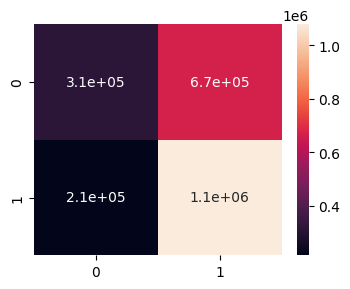

In [82]:
plt.figure(figsize = (4,3))
sns.heatmap(confmax_lgbmc, annot = True)
plt.show()

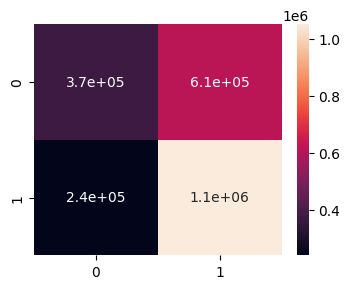

In [83]:
plt.figure(figsize = (4,3))
sns.heatmap(confmax_xgbc, annot = True)
plt.show()